
### Testing `powergrid.py` Graphs 

**Notes:**
1. Small resistances $B_{kl} = \frac{X_{kl}}{R^2_{kl}+X_{kl}^2} \approx X_{kl}^{-1}$ is not a good approximation. So we include resistances $\implies$ we have to be careful with ieee57 because this data set does NOT fulfill $X_{kl} \gg R_{kl}$ and it is a basic assumption for the **DC Pwerflow approxmiation**
2. Off-Diagonal Elements $B[i,j] = - b_{ij}$, Diagonal $B[i,i] = \sum_j B_{}ij$
3. DC Power Approximation $P_{kl} = \frac{\theta_k - \theta_l}{X_{kl}} \implies B \theta = P$ might not be a good approximatin for ieee57, implement `PowerGrid.random()` grid with  $X_{kl} \gg R_{kl}$ 


**IEEE57 Data Set**

In [15]:
%load_ext autoreload
%autoreload 2

# Auxilary 
from powergrid import *
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 


#Plot Power Grid Graph
def plot_grid(pg: PowerGrid):     
    G = nx.from_scipy_sparse_array(pg.graph)
    pos = nx.spring_layout(G)  # layout of the nodes
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
    # Draw edges
    nx.draw_networkx_edges(G, pos, width=2)
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=12)
    plt.axis('off')
   # plt.show()

def plot_B(pg: Powergrid): 
    plt.imshow(pg.B.toarray(), cmap='coolwarm')
    plt.title(r'$B_{kl}$ of ieee57')
    plt.xlabel('k')
    plt.ylabel('l')
    plt.colorbar()
    #plt.show()

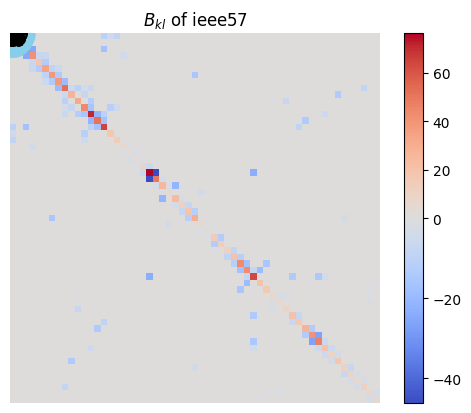

In [11]:
# Visualizing the IEEE57 Data Set

#print(pg.B)
#print(type(pg.P))
#print(pg.B.shape)
#print(pg.P.shape)
#print(pg.P)

pg = PowerGrid.ieee57()
plot_grid(pg)
plot_B(pg)

**Random Power Grids**

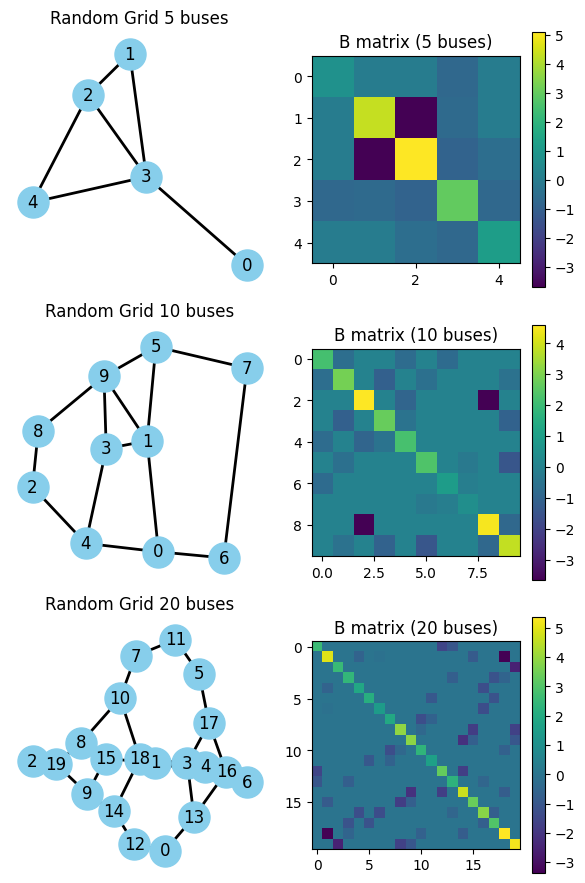

In [14]:
import matplotlib.pyplot as plt

n_vals = [5, 10, 20]
num_generators = 3
RPGs = [PowerGrid.random(n, num_generators=num_generators) for n in n_vals]

n_grids = len(RPGs)
fig, axes = plt.subplots(n_grids, 2, figsize=(6, 3*n_grids))  # 2 columns: grid + B

for i, rpg in enumerate(RPGs):
    # Plot network topology
    plt.sca(axes[i, 0])
    plot_grid(rpg)  # make sure this plots on current axes
    plt.title(f'Random Grid {rpg.n} buses')

    # Plot B matrix
    plt.sca(axes[i, 1])
    plt.imshow(rpg.B.toarray(), cmap='viridis')
    plt.colorbar()
    plt.title(f'B matrix ({rpg.n} buses)')
plt.tight_layout()
plt.show()

### Testing `powergrid.py` 
1. Physics Sanity Checks
2. Tiny Graphs with known behavior
3. Behavioral tests of loss function

In [ ]:
# 1. 
# -- A. Zero injections give zero angles and zero flow
# ---- create tiny graph where all loads and generators are zero
# ---- reactances and resistances have unit value 1
# ---- Expected: all vectors are zero

graph = nx.circulant_graph(n=4, offsets=[1])
print('Edges set', graph.edges())
busses = []
branches = []
for i, edge in enumerate(graph.edges()):
    bus = Bus(idx=i, load=0, generation=0)
    busses.append(bus)
    branch = Branch(from_bus=edge[0]+1, to_bus=edge[1]+1, reactance=1, resistance=1) # don't forget about indexing
    branches.append(branch)
pg = PowerGrid(busses, branches)

print('P vector', pg.P)
theta = pg.solve_lse(pg.P)
print('Theta vectr', theta)
rho = pg.compute_line_flows(theta)
print('Rho vector', rho)
print('>> correct results')

Edges set [(0, 3), (0, 1), (1, 2), (2, 3)]
P vector [0. 0. 0. 0.]
Theta vectr [0. 0. 0. 0.]
Rho vector [0. 0. 0. 0.]
>> correct results


In [73]:
# 2.
# -- Test 1: 3-busses, 2-line system (1 generator, total power is conserved)
graph = nx.circulant_graph(n=3, offsets=[1])
print('Edges set', graph.edges())
busses = []
branches = []
for i, edge in enumerate(graph.edges()):
    bus = Bus(idx=i, load=0.5 if i != 0 else 0, generation=1 if i == 0 else 0)
    busses.append(bus)
    branch = Branch(from_bus=edge[0]+1, to_bus=edge[1]+1, reactance=1, resistance=1) # don't forget about indexing
    branches.append(branch)
pg = PowerGrid(busses, branches)

print(busses, '\n')


print('>> format (loss_function value, sum_i P_i mismatch)')
print(pg.loss_function(x=[1])) # 
print('>> Minimum of loss function, power flow is conserved -> No penalty term')
print(pg.loss_function(x=[0])) # Violates energy conservation. Hence penalty term dominates
print('>> Power flow is no longer conserved -> Penalty term dominates')
print(50*'-')

# -- Test 2: 3-busses, 2-line system (1 generator, total power is no longer conserved)
graph = nx.circulant_graph(n=3, offsets=[1])
print('Edges set', graph.edges())
busses = []
branches = []
for i, edge in enumerate(graph.edges()):
    bus = Bus(idx=i, load=1 if i != 0 else 0, generation=1 if i == 0 else 0) # new: loads are now 1 (system overloaded)
    busses.append(bus)
    branch = Branch(from_bus=edge[0]+1, to_bus=edge[1]+1, reactance=1, resistance=1)
    branches.append(branch)
pg = PowerGrid(busses, branches)
print(busses, '\n')

print('>> format (loss_function value, sum_i P_i mismatch)')
print(pg.loss_function(x=[1])) # 
print('>> Minimum of loss function, power flow is not conserved -> Penalty term')
print(pg.loss_function(x=[0])) # Violates energy conservation. Hence penalty term dominates
print('>> Even stronger violation of power conservation')


Edges set [(0, 2), (0, 1), (1, 2)]
[Bus(idx=0, load=0, generation=1), Bus(idx=1, load=0.5, generation=0), Bus(idx=2, load=0.5, generation=0)] 

>> format (loss_function value, sum_i P_i mismatch)
(np.float64(1.0), np.float64(0.0))
>> Minimum of loss function, power flow is conserved -> No penalty term
(np.float64(10001.0), np.float64(-1.0))
>> Power flow is no longer conserved -> Penalty term dominates
--------------------------------------------------
Edges set [(0, 2), (0, 1), (1, 2)]
[Bus(idx=0, load=0, generation=1), Bus(idx=1, load=1, generation=0), Bus(idx=2, load=1, generation=0)] 

>> format (loss_function value, sum_i P_i mismatch)
(np.float64(10002.0), np.float64(-1.0))
>> Minimum of loss function, power flow is not conserved -> Penalty term
(np.float64(20002.0), np.float64(-2.0))
>> Even stronger violation of power conservation


In [74]:

# -- Test 3: 3-busses, 2-line system (2 generators, total power is conserved)
graph = nx.circulant_graph(n=3, offsets=[1])
print('Edges set', graph.edges())
busses = []
branches = []
for i, edge in enumerate(graph.edges()):
    bus = Bus(idx=i, load=1 if i == 0 else 0, generation=0.5 if i != 0 else 0) # new: we now have 2 generators, power is conserved
    busses.append(bus)
    branch = Branch(from_bus=edge[0]+1, to_bus=edge[1]+1, reactance=1, resistance=1) 
    branches.append(branch)
pg = PowerGrid(busses, branches)
print(busses, '\n')

print('>> format (loss_function value, sum_i P_i mismatch)')
print(pg.loss_function(x=[1, 1])) # Both generators are turned on. Power flow is conserved. Expected: minimum
print('>> Minimum of loss function, power conservation')
print(pg.loss_function(x=[0, 1])) # Violates energy conservation. Hence penalty term dominates
print(pg.loss_function(x=[1, 0])) # Violates energy conservation. Hence penalty term dominates
print('>> Power is no longer conserved in both cases, but problem is symmetric under generator-exchange')
print(pg.loss_function(x=[0, 0])) # Even worse violation
print('>> Even worse violation of power conservation -> Largest Penalty')
print(50*'-')


# -- Test 4: 3-busses, 2-line system (2 generators, but different costs)
graph = nx.circulant_graph(n=3, offsets=[1])
print('Edges set', graph.edges())
busses = []
branches = []
for i, edge in enumerate(graph.edges()):
    bus = Bus(idx=i, load=1 if i == 0 else 0, generation=1 if i != 0 else 0) # new: still 2 generators
    busses.append(bus)
    branch = Branch(from_bus=edge[0]+1, to_bus=edge[1]+1, reactance=1, resistance=1) 
    branches.append(branch)
pg = PowerGrid(busses, branches)
print(busses, '\n')
# now we change the costs!
print('>> format (loss_function value, sum_i P_i mismatch)')
print(pg.loss_function(x=[1, 1], c=[1, 10000, 1])) # lets make one generator very expensive, s.t. it exceeds conservation penalty
print('>> Both generators turned on. One is very expensive. Thus the high cost adds to cost function')
print(pg.loss_function(x=[0, 1], c=[1, 10000, 1])) # Violates energy conservation. Hence penalty term dominates
print('>> Expensive generator is now turned off. Penalty term dominates now, but overall cost is still lower')
print(pg.loss_function(x=[0, 0], c=[1, 10000, 10000])) # Even worse violation
print('>> Both generators are now expensive and turned off. Net cost is still lower')






Edges set [(0, 2), (0, 1), (1, 2)]
[Bus(idx=0, load=1, generation=0), Bus(idx=1, load=0, generation=0.5), Bus(idx=2, load=0, generation=0.5)] 

>> format (loss_function value, sum_i P_i mismatch)
(np.float64(1.0), np.float64(0.0))
>> Minimum of loss function, power conservation
(np.float64(5000.666666666667), np.float64(-0.5))
(np.float64(5000.666666666667), np.float64(-0.5))
>> Power is no longer conserved in both cases, but problem is symmetric under generator-exchange
(np.float64(10000.0), np.float64(-1.0))
>> Even worse violation of power conservation -> Largest Penalty
--------------------------------------------------
Edges set [(0, 2), (0, 1), (1, 2)]
[Bus(idx=0, load=1, generation=0), Bus(idx=1, load=0, generation=1), Bus(idx=2, load=0, generation=1)] 

>> format (loss_function value, sum_i P_i mismatch)
(np.float64(20001.0), np.float64(1.0))
>> Both generators turned on. One is very expensive. Thus the high cost adds to cost function
(np.float64(3334.333333333333), np.float64(

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from powergrid import *

pg = PowerGrid.ieee57()
print(pg.num_generators)
print(pg.generator_positions)

4
[0, 2, 7, 11]
